In [ ]:

import sys
sys.path.append("..//")

from batchAQUA_general import batchAQUA
from AQUA_general import AQUA
from stimulus import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
import pickle
import random


from simulation import get_F

In [ ]:
# initial tests on RS_int

neuron = "RS_biexp"
out_dir = f".//{neuron}//"

filename = f"{neuron}_test.pickle"
with open(filename, 'rb') as file:
    df = pickle.load(file)

print(df.keys())
print(df["F_steady"])

Index(['e', 'f', 'tau', 'I_h', 'F_instant', 'F_steady', 'autapse current',
       'autapse delay'],
      dtype='object')
0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
1095    94.786730
1096    93.896714
1097    93.023256
1098    91.743119
1099    90.909091
Name: F_steady, Length: 50100, dtype: float64


[0.         0.1        0.14444444 0.18888889 0.23333333 0.27777778
 0.32222222 0.36666667 0.41111111 0.45555556 0.5       ]
[  0.          50.          72.22222222  94.44444444 116.66666667
 138.88888889 161.11111111 183.33333333 205.55555556 227.77777778
 250.        ]


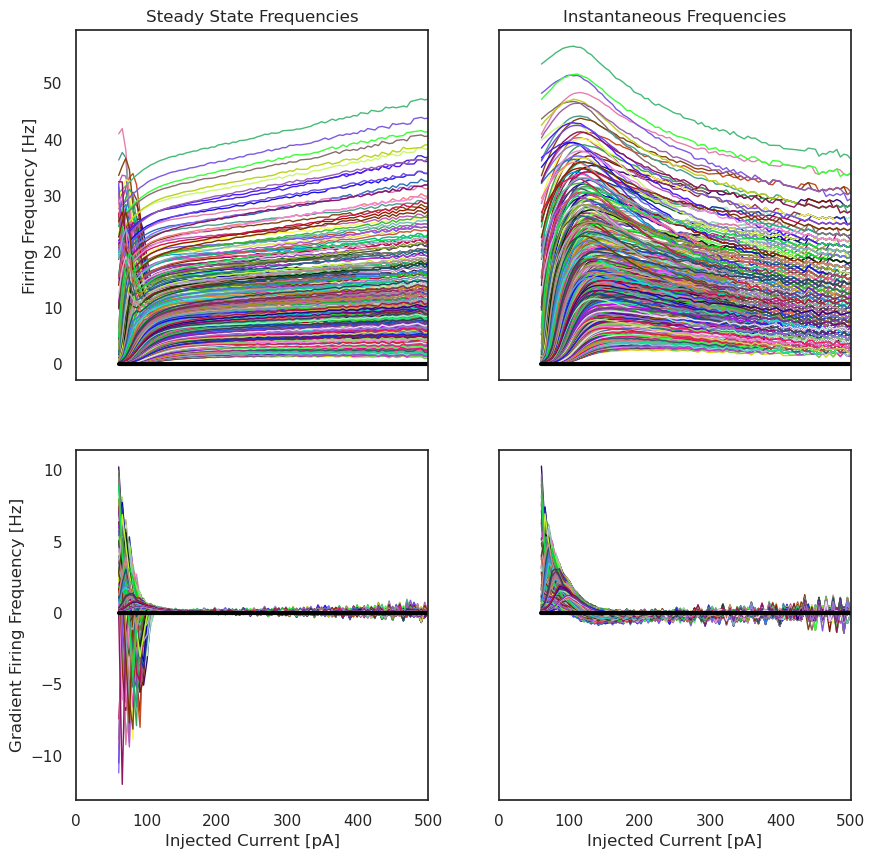

In [ ]:
### Extract relevant data and plot relative to the non-autaptic neuron

e_vals = df["e"].unique()
f_vals = df["f"].unique()
tau_vals = df["tau"].unique()

print(e_vals)
print(f_vals)

# Get plotting data in I-O curves
fig, ax = plt.subplots(2, 2, figsize = (10, 10), sharex = True, sharey = 'row')

# get baseline data
sub_df = df[(df["e"] == 0.) & (df["f"] == 0.) & (df["tau"] == 0.)].copy()

sub_df.sort_values(by = ["I_h"])
I_h_base = np.array(sub_df["I_h"])
F_steady_base = np.array(sub_df["F_steady"])
grad_f_steady_base = np.ediff1d(F_steady_base, to_end = 0.0)
F_instant_base = np.array(sub_df["F_instant"])
grad_f_instant_base = np.ediff1d(F_instant_base, to_end = 0.0)


for e in np.flip(e_vals):
    for f in np.flip(f_vals):
        for tau in np.flip(tau_vals):
            # colours for plotting
            if e == 0.0 and f == 0.0 and tau == 0.0:
                colour = (0., 0., 0.)
                linewidth = 3
            else:
                colour = tuple(np.random.rand(3))   # colour for individual neurons
                linewidth = 1
        
            # get relevant neuron with autapse parameters
            sub_df = df[(df["e"] == e) & (df["f"] == f) & (df["tau"] == tau)].copy()
            #if the neuron doesn't exist, move on
            if sub_df.empty:
                continue

            sub_df.sort_values(by = ["I_h"])

            I_h = np.array(sub_df["I_h"])
            F_steady = np.array(sub_df["F_steady"]) - F_steady_base
            grad_f_steady = np.ediff1d(F_steady, to_end = 0.0)
            F_instant = np.array(sub_df["F_instant"]) - F_instant_base
            grad_f_instant = np.ediff1d(F_instant, to_end = 0.0)

            ax[0, 0].plot(I_h, F_steady, c = colour, linewidth = linewidth)
            ax[0, 1].plot(I_h, F_instant, c = colour, linewidth = linewidth)
            ax[1, 0].plot(I_h, grad_f_steady, c = colour, linewidth = linewidth)
            ax[1, 1].plot(I_h, grad_f_instant, c = colour, linewidth = linewidth)


ax[0, 0].set_xlim((np.min(I_h), np.max(I_h)))
ax[0, 0].set_ylabel("Firing Frequency [Hz]")
ax[1, 0].set_ylabel("Gradient Firing Frequency [Hz]")
ax[1, 0].set_xlabel("Injected Current [pA]")
ax[1, 1].set_xlabel("Injected Current [pA]")

ax[0, 0].set_title("Steady State Frequencies")
ax[0, 1].set_title("Instantaneous Frequencies")

plt.savefig(out_dir + "I-O_gain_and_derivatives.png")

In [ ]:
### Extracted data is going to be relative to the baseline non-autaptic neuron response

e_vals = df["e"].unique()
e_vals = np.delete(e_vals, 0)
f_vals = df["f"].unique()
f_vals = np.delete(f_vals, 0)
tau_vals = df["tau"].unique()


N_neurons = 1 + len(e_vals)*len(f_vals)*len(tau_vals)
print(f"N_neurons: {N_neurons}")

# output arrays
autapse_current = np.zeros(N_neurons)
f_value = np.zeros(N_neurons)
e_value = np.zeros(N_neurons)
autapse_delay = np.zeros(N_neurons)
instant_gradient = np.zeros(N_neurons)
peak_instant_grad = np.zeros(N_neurons)
area_steady = np.zeros(N_neurons)

# get non-autaptic results
sub_df = df[(df["e"] == 0.) & (df["f"] == 0.) & (df["tau"] == 0.)].copy()
sub_df.sort_values(by = ["I_h"])
I_h_base = np.array(sub_df["I_h"])
F_steady_base = np.array(sub_df["F_steady"])
grad_f_steady_base = np.ediff1d(F_steady_base, to_end = 0.0)
F_instant_base = np.array(sub_df["F_instant"])
grad_f_instant_base = np.ediff1d(F_instant_base, to_end = 0.0)


count = 0       # count the neurons encountered
for e in np.flip(e_vals):
    for f in np.flip(f_vals):
        for tau in np.flip(tau_vals):
        
            # get relevant neuron with autapse parameters
            sub_df = df[(df["e"] == e) & (df["f"] == f) & (df["tau"] == tau)].copy()
            if sub_df.empty:
                continue
            else:
                sub_df.sort_values(by = ["I_h"])

                # responses are made relative to the non-autaptic neuron
                F_steady = np.array(sub_df["F_steady"]) - F_steady_base
                grad_f_steady = np.ediff1d(F_steady, to_end = 0.0)
                F_instant = np.array(sub_df["F_instant"]) - F_instant_base
                grad_f_instant = np.ediff1d(F_instant, to_end = 0.0)

                # get properties of the autapse
                autapse_current[count] = sub_df["autapse current"].unique()[0]
                f_value[count] = sub_df["f"].unique()[0]
                e_value[count] = sub_df["e"].unique()[0]
                autapse_delay[count] = sub_df["autapse delay"].unique()[0]
                # get properties of the response
                instant_gradient[count] = np.sum(grad_f_instant[~np.isnan(grad_f_instant)])                                 # area under the instantaneous derivative curve
                peak_instant_grad[count] = np.max(grad_f_instant[~np.isnan(grad_f_instant)])                                # peak instantaneous gradient                                          # peak instantaneous response
                area_steady[count] = np.abs(np.sum(grad_f_steady[(~np.isnan(grad_f_steady)) & (grad_f_steady < 0.)]))       # the area under the negative portion of the steady gradient curve

                count += 1

autapse_current = np.nan_to_num(autapse_current, 0.)
autapse_delay = np.nan_to_num(autapse_delay, 0.)
sort_idx = np.argsort(autapse_current)

autapse_current = np.round(autapse_current, 0)
autapse_delay = np.round(autapse_delay, 2)
f_value = np.round(f_value, 1)
e_value = np.round(e_value, 2)

dict = {"autapse current": autapse_current[sort_idx],
        "f value": f_value[sort_idx],
        "e value": e_value[sort_idx],
        "autapse delay": autapse_delay[sort_idx],
        "instant gradient": instant_gradient[sort_idx],
        "peak instant grad": peak_instant_grad[sort_idx],
        "area steady": area_steady[sort_idx]}
new_df = pd.DataFrame(dict)

N_neurons: 501


WARNING    /tmp/ipykernel_235532/2445707518.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 45, ha = 'right')
 [py.warnings]
WARNING    /tmp/ipykernel_235532/2445707518.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation = 45, ha = 'right')
 [py.warnings]


[   0.  100.  110.  122.  136.  144.  155.  159.  176.  180.  189.  197.
  207.  214.  224.  230.  233.  256.  258.  260.  265.  278.  284.  293.
  305.  310.  318.  322.  338.  340.  346.  354.  362.  367.  379.  382.
  392.  402.  405.  411.  420.  431.  439.  446.  451.  456.  500.  549.
  554.  561.  569.  580.  595.  608.  618.  621.  638.  654.  660.  682.
  690.  707.  722.  735.  740.  776.  786.  808.  820.  853.  881.  900.
  944.  962.  971.  976. 1071. 1088. 1115. 1167. 1206. 1269. 1324. 1389.
 1423. 1577. 1611. 1731. 1833. 2056. 2278. 2500.]


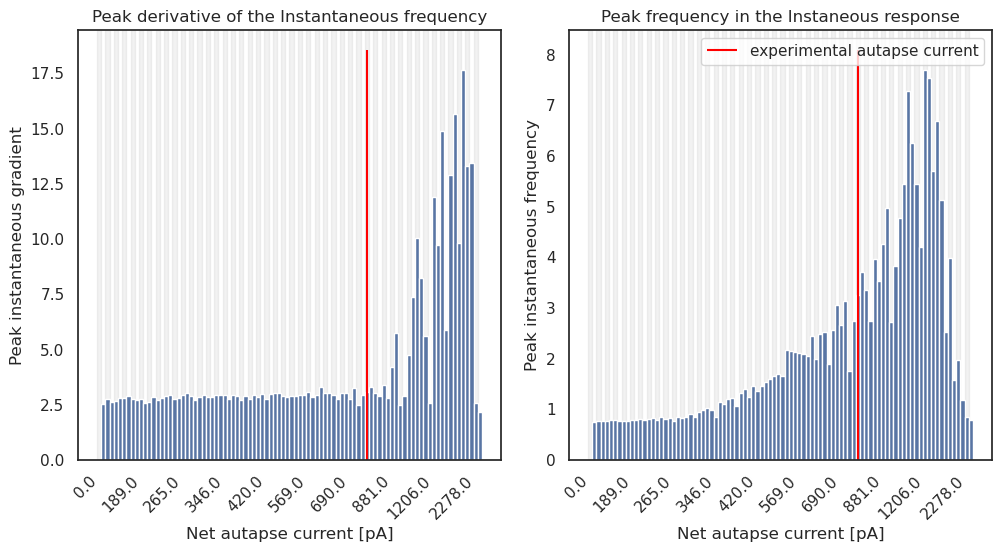

In [ ]:
"""
Plot of derivative metrics as a function of some autapse parameter metrics (net current and delay)

"""

fig, ax = plt.subplots(1, 2, figsize = (10, 5))
plt.tight_layout()

#sns.barplot(data = new_df, x = "autapse current", y = "area steady", hue = "autapse delay", palette = 'viridis', ax = ax[0], width = 1.)
#sns.barplot(data = new_df, x = "autapse current", y = "instant gradient", hue = "autapse delay", palette = 'viridis', ax = ax[1], width = 1., legend = False)
sns.barplot(data = new_df, x = "autapse current", y = "area steady", ax = ax[0], width = 1., legend = False, errorbar = None)
sns.barplot(data = new_df, x = "autapse current", y = "peak instant grad", ax = ax[1], width = 1., legend = False, errorbar = None)

# create a legend for the whole figure
#handles, labels = ax[0].get_legend_handles_labels()     # get legend from ax[0]
#ax[0].get_legend().remove()                             # delete legend data
#fig.legend(handles, labels, title='Autapse Delay', loc='center right', 
#           bbox_to_anchor=(1.15, 0.5))

# Loop through the number of categories on your x-axis
for i in range(len(new_df["autapse current"].unique())):
    if i % 2 == 0:
        ax[0].axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)
        ax[1].axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)

ax[0].set_ylabel("Peak instantaneous gradient")
ax[1].set_ylabel("Peak instantaneous frequency")

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 45, ha = 'right')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation = 45, ha = 'right')

# add a red line at the biological autapse
labels = np.array([float(t.get_text()) for t in ax[0].get_xticklabels()])
print(labels)
aut_exp = 750   # (f/e)
x_pos = np.argmin(np.abs(labels - aut_exp))

ax[0].vlines(x_pos, ax[0].get_ylim()[0], ax[0].get_ylim()[1], color = 'red', label = 'experimental autapse current')
ax[1].vlines(x_pos, ax[1].get_ylim()[0], ax[1].get_ylim()[1], color = 'red', label = 'experimental autapse current')
plt.legend()


#only show every 10th tick label
tick_spacing = 10
positions = range(0, len(df), tick_spacing)
for ind, label in enumerate(ax[0].get_xticklabels()):
    if ind % 10 == 0:  # Keep the 0th, 10th, 20th...
        label.set_visible(True)
    else:
        label.set_visible(False)

for ind, label in enumerate(ax[1].get_xticklabels()):
    if ind % 10 == 0:  # Keep the 0th, 10th, 20th...
        label.set_visible(True)
    else:
        label.set_visible(False)


ax[0].set_title("Peak derivative of the Instantaneous frequency")
ax[1].set_title("Peak frequency in the Instaneous response")
ax[0].set_xlabel("Net autapse current [pA]")
ax[1].set_xlabel("Net autapse current [pA]")


plt.show()

##### Plot results (for RS_intHD):

-> There is a region slightly past the experimental autapse where the I-O curve becomes very sensitive to the input frequency
    (Left plot, high derivative in the instaneous I-O curve)

    
-> There is a roughly linear relationship between the peak instaneous response frequency and the net current through the autapse
    (This is expected behaviour, as the autapse just pumps more current through the neurons)

In [ ]:
### Look at the trend between the peak instant gradient and the corresponding I_h at which it occurs
# use: sns.scatter(x = 'I_h_at_peak', y = 'peak_instant_grad', hue = 'autapse current')
# copy of the above process

### Data NOT relative to baseline!

e_vals = df["e"].unique()
e_vals = np.delete(e_vals, 0)
f_vals = df["f"].unique()
f_vals = np.delete(f_vals, 0)
tau_vals = df["tau"].unique()


N_neurons = 1 + len(e_vals)*len(f_vals)*len(tau_vals)
print(f"N_neurons: {N_neurons}")

# output arrays
autapse_current = np.zeros(N_neurons)
f_value = np.zeros(N_neurons)
e_value = np.zeros(N_neurons)
autapse_delay = np.zeros(N_neurons)
instant_gradient = np.zeros(N_neurons)
peak_instant_grad = np.zeros(N_neurons)
I_h_at_peak = np.zeros(N_neurons)


count = 0       # count the neurons encountered
for e in np.flip(e_vals):
    for f in np.flip(f_vals):
        for tau in np.flip(tau_vals):
        
            # get relevant neuron with autapse parameters
            sub_df = df[(df["e"] == e) & (df["f"] == f) & (df["tau"] == tau)].copy()
            if sub_df.empty:
                continue
            else:
                sub_df.sort_values(by = ["I_h"])

                # responses are made relative to the non-autaptic neuron
                I_h = np.array(sub_df["I_h"])
                F_steady = np.array(sub_df["F_steady"])
                F_steady = np.nan_to_num(F_steady, nan = 0.)
                grad_f_steady = np.ediff1d(F_steady, to_end = 0.0)
                F_instant = np.array(sub_df["F_instant"])
                F_instant = np.nan_to_num(F_instant, nan = 0.0)
                grad_f_instant = np.ediff1d(F_instant, to_end = 0.0)

                # get properties of the autapse
                autapse_current[count] = sub_df["autapse current"].unique()[0]
                f_value[count] = sub_df["f"].unique()[0]
                e_value[count] = sub_df["e"].unique()[0]
                autapse_delay[count] = sub_df["autapse delay"].unique()[0]
                # get properties of the response
                instant_gradient[count] = np.sum(grad_f_instant[~np.isnan(grad_f_instant)])         # area under the instantaneous derivative curve
                peak_instant_grad[count] = np.max(grad_f_instant)                                   # peak instantaneous gradient
                peak_grad_idx = np.argmax(grad_f_instant)
                I_h_at_peak[count] = I_h[peak_grad_idx]
                count += 1

autapse_current = np.nan_to_num(autapse_current, 0.)
autapse_delay = np.nan_to_num(autapse_delay, 0.)
sort_idx = np.argsort(autapse_current)

autapse_current = np.round(autapse_current, 0)
autapse_delay = np.round(autapse_delay, 2)
f_value = np.round(f_value, 1)
e_value = np.round(e_value, 2)

dict = {"autapse current": autapse_current[sort_idx],
        "f value": f_value[sort_idx],
        "e value": e_value[sort_idx],
        "autapse delay": autapse_delay[sort_idx],
        "instant gradient": instant_gradient[sort_idx],
        "peak instant grad": peak_instant_grad[sort_idx],
        "I_h at peak": I_h_at_peak[sort_idx]}

new_df = pd.DataFrame(dict)

N_neurons: 501


<Axes: xlabel='I_h at peak', ylabel='peak instant grad'>

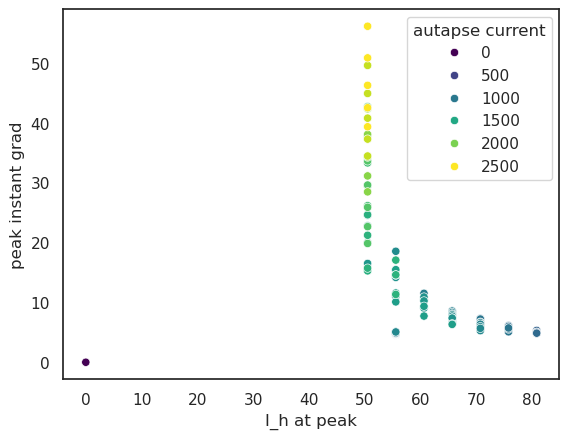

In [ ]:
sns.scatterplot(data = new_df, x = "I_h at peak", y = "peak instant grad", hue = "autapse current", palette = "viridis")